# Introductory task for Applied Artificial Intelligence Lab

## Relevant information

I am an ERASMUS student, so I am only here for this semester. 

During my last semester in France, I passed a class about data analysis where I learned how to process and clean the data. I also learned about PCA, CCA, FCA and clustering algorithms.

Another class was about regression algorithms, where I applied linear regression, logistic regression with regularization such as Lasso and Ridge.

# Rainy or Sunny classifier

In [11]:
import os
import pandas as pd
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader, random_split
import re
import csv
import matplotlib.pyplot as plt
import torch

In [8]:
weather_to_idx = {"rainy": 0, "sunny": 1}

class WeatherDataset(Dataset):
    def __init__(self, annotations_file, img_dir, transform=None):
        self.img_labels = pd.read_csv(annotations_file)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx, 0])
        image = read_image(img_path)
        label_name = self.img_labels.iloc[idx, 1]
        label = weather_to_idx[label_name]
        if self.transform:
            image = self.transform(image)
        return image, label

In [9]:
img_path = "data/all_except_marked"

data = []
for filename in os.listdir(img_path):
    if filename.lower().endswith(('.png')):
        match = re.match(r"image_\d*(\D+)_(\w+)\.\w+", filename)
        if match:
            style = match.group(1)   # "realistic"
            weather = match.group(2) # "rainy"
            data.append([filename, weather, style])
        else:
            print(f"Nom inattendu : {filename}")
            
csv_path = os.path.join(img_path, "image_metadata.csv")
with open(csv_path, "w", newline="") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["filename", "weather", "style"])
    writer.writerows(data)

In [21]:
first_dataset = WeatherDataset(annotations_file=csv_path, img_dir=img_path)

train_size = int(0.8 * len(first_dataset))
test_size = len(first_dataset) - train_size

train_dataset, test_dataset = random_split(first_dataset, [train_size, test_size])

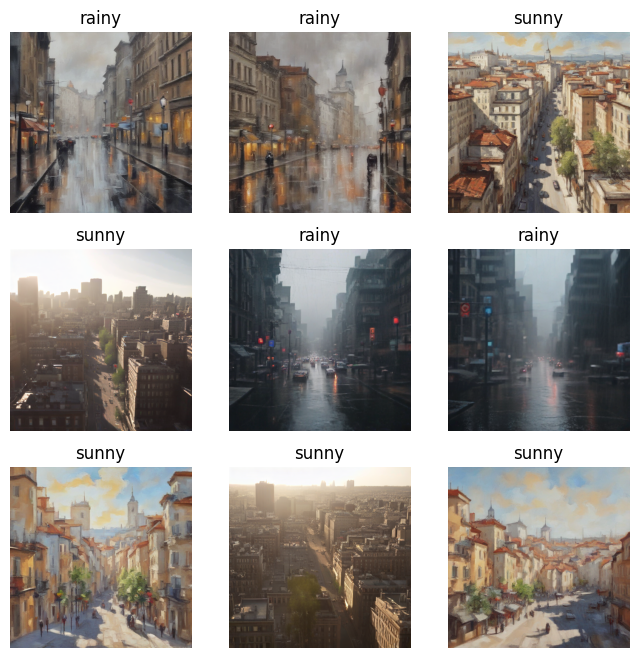

In [ ]:
labels_map = {v: k for k, v in weather_to_idx.items()}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_dataset), size=(1,)).item()
    img, label = train_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.permute(1, 2, 0))
plt.show()